In [1]:
import mne
from mne.decoding import Vectorizer

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support

# Models
from sklearn import svm
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression

import matplotlib
import matplotlib.pyplot as plt
import numpy as np

In [2]:
data_file = 'epoch_data/kr values deu neg'

# Read the EEG epochs:
epochs = mne.read_epochs(data_file + '.fif', verbose='error')

In [3]:
epochs_ICN = epochs['IC', 'N'] # Incongruent vs. Neutral
epochs_ICC = epochs['IC', 'C'] # Incongruent vs. Congruent
epochs_NC = epochs['N', 'C'] # Neutral vs. Congruent

accuracies, f1_scores = [], []

In [4]:
# Task-1: Classification between Unpleasant and Neutral Events 

epochs = epochs_ICN

# Dataset with incongruent and neutral events
data = epochs.get_data()
labels = epochs.events[:,-1]

train_data, test_data, labels_train, labels_test = train_test_split(data, labels, test_size=0.3, random_state=42)
clf_svm_0 = make_pipeline(Vectorizer(), StandardScaler(), svm.SVC(kernel='rbf', C=1))
clf_svm_0 = make_pipeline(Vectorizer(), StandardScaler(), svm.SVC(kernel='rbf', C=1))
scores = cross_val_score(clf_svm_0, data, labels, cv=5)
for i in range(len(scores)):   
    print('Accuracy of ' + str(i+1) + 'th fold is ' + str(scores[i]) + '\n')

#svm
clf_svm_pip = make_pipeline(Vectorizer(), StandardScaler(), svm.SVC(random_state=42))
parameters = {'svc__kernel':['linear', 'rbf', 'sigmoid'], 'svc__C':[0.1, 1, 10]}
gs_cv_svm = GridSearchCV(clf_svm_pip, parameters, scoring='accuracy', cv=StratifiedKFold(n_splits=5), return_train_score=True)
gs_cv_svm.fit(train_data, labels_train)
print('Best Parameters: {}'.format(gs_cv_svm.best_params_))
print('Best Score: {}'.format(gs_cv_svm.best_score_))
#Prediction
predictions_svm = gs_cv_svm.predict(test_data)
#Evaluate
report_svm = classification_report(labels_test, predictions_svm, target_names=['Incongruent', 'Neutral'])
print('SVM Clasification Report:\n {}'.format(report_svm))
acc_svm = accuracy_score(labels_test, predictions_svm)
print("Accuracy of SVM model: {}".format(acc_svm))
precision_svm,recall_svm,fscore_svm,support_svm=precision_recall_fscore_support(labels_test,predictions_svm,average='macro')
print('Precision: {0}, Recall: {1}, f1-score:{2}'.format(precision_svm,recall_svm,fscore_svm))

# Logistic Regression
clf_lr_pip = make_pipeline(Vectorizer(), StandardScaler(), LogisticRegression(random_state=42))
parameters = {'logisticregression__penalty':['l1', 'l2']}
gs_cv_lr = GridSearchCV(clf_lr_pip, parameters, scoring='accuracy')
gs_cv_lr.fit(train_data, labels_train)
print('Best Parameters: {}'.format(gs_cv_lr.best_params_))
print('Best Score: {}'.format(gs_cv_lr.best_score_))
#Predictions
predictions_lr = gs_cv_lr.predict(test_data)
#Evaluation
report_lr = classification_report(labels_test, predictions_lr, target_names=['Incongruent', 'Neutral'])
print('LR Clasification Report:\n {}'.format(report_lr))
acc_lr = accuracy_score(labels_test, predictions_lr)
print("Accuracy of LR model: {}".format(acc_lr))
precision_lr,recall_lr,fscore_lr,support_lr=precision_recall_fscore_support(labels_test,predictions_lr,average='macro')
print('Precision: {0}, Recall: {1}, f1-score:{2}'.format(precision_lr,recall_lr,fscore_lr))

# Linear Discriminant Analysis
clf_lda_pip = make_pipeline(Vectorizer(), StandardScaler(), LinearDiscriminantAnalysis(solver='svd'))
clf_lda_pip.fit(train_data,labels_train)
#Predictions
predictions_lda = clf_lda_pip.predict(test_data)
#Evaluation
report_lda = classification_report(labels_test, predictions_lda, target_names=['Incongruent', 'Neutral'])
print('LDA Clasification Report:\n {}'.format(report_lda))
acc_lda = accuracy_score(labels_test, predictions_lda)
print("Accuracy of LDA model: {}".format(acc_lda))
precision_lda,recall_lda,fscore_lda,support_lda=precision_recall_fscore_support(labels_test,predictions_lda,average='macro')
print('Precision: {0}, Recall: {1}, f1-score:{2}'.format(precision_lda,recall_lda,fscore_lda))

accuracies.append([acc_svm, acc_lr, acc_lda])
f1_scores.append([fscore_svm, fscore_lr, fscore_lda])
print('Support Vector Machines, Logistic Regression, Linear Discriminant Analysis')
print('')
print('accuracies', accuracies)
print('f1_scores', f1_scores)

C:\Users\serha\AppData\Local\Temp\ipykernel_12956\2665698473.py:6: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


Accuracy of 1th fold is 0.5714285714285714

Accuracy of 2th fold is 0.8333333333333334

Accuracy of 3th fold is 0.6666666666666666

Accuracy of 4th fold is 0.5

Accuracy of 5th fold is 0.5

Best Parameters: {'svc__C': 10, 'svc__kernel': 'sigmoid'}
Best Score: 0.63
SVM Clasification Report:
               precision    recall  f1-score   support

 Incongruent       0.33      0.25      0.29         4
     Neutral       0.57      0.67      0.62         6

    accuracy                           0.50        10
   macro avg       0.45      0.46      0.45        10
weighted avg       0.48      0.50      0.48        10

Accuracy of SVM model: 0.5
Precision: 0.45238095238095233, Recall: 0.4583333333333333, f1-score:0.45054945054945056


C:\Users\serha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py:542: FitFailedWarning: 
5 fits failed out of a total of 10.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\serha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_validation.py", line 890, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\serha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py", line 1351, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\serha\AppData\

Best Parameters: {'logisticregression__penalty': 'l2'}
Best Score: 0.43
LR Clasification Report:
               precision    recall  f1-score   support

 Incongruent       0.40      0.50      0.44         4
     Neutral       0.60      0.50      0.55         6

    accuracy                           0.50        10
   macro avg       0.50      0.50      0.49        10
weighted avg       0.52      0.50      0.51        10

Accuracy of LR model: 0.5
Precision: 0.5, Recall: 0.5, f1-score:0.4949494949494949
LDA Clasification Report:
               precision    recall  f1-score   support

 Incongruent       0.25      0.25      0.25         4
     Neutral       0.50      0.50      0.50         6

    accuracy                           0.40        10
   macro avg       0.38      0.38      0.38        10
weighted avg       0.40      0.40      0.40        10

Accuracy of LDA model: 0.4
Precision: 0.375, Recall: 0.375, f1-score:0.375
Support Vector Machines, Logistic Regression, Linear Discrimina

In [5]:
#Task-2: Classification between Incongruent and Congruent Events
epochs = epochs_ICC

# Dataset with incongruent and neutral events
data = epochs.get_data()
labels = epochs.events[:,-1]

train_data, test_data, labels_train, labels_test = train_test_split(data, labels, test_size=0.3, random_state=42)
#clf_svm_0 = make_pipeline(Vectorizer(), StandardScaler(), svm.SVC(kernel='rbf', C=1))
#clf_svm_0 = make_pipeline(Vectorizer(), StandardScaler(), svm.SVC(kernel='rbf', C=1))
#scores = cross_val_score(clf_svm_0, data, labels, cv=5)
#for i in range(len(scores)):   
#    print('Accuracy of ' + str(i+1) + 'th fold is ' + str(scores[i]) + '\n')

#svm
clf_svm_pip = make_pipeline(Vectorizer(), StandardScaler(), svm.SVC(random_state=42))
parameters = {'svc__kernel':['linear', 'rbf', 'sigmoid'], 'svc__C':[0.1, 1, 10]}
gs_cv_svm = GridSearchCV(clf_svm_pip, parameters, scoring='accuracy', cv=StratifiedKFold(n_splits=5), return_train_score=True)
gs_cv_svm.fit(train_data, labels_train)
print('Best Parameters: {}'.format(gs_cv_svm.best_params_))
print('Best Score: {}'.format(gs_cv_svm.best_score_))
#Prediction
predictions_svm = gs_cv_svm.predict(test_data)
#Evaluate
report_svm = classification_report(labels_test, predictions_svm, target_names=['Incongruent', 'Neutral'])
print('SVM Clasification Report:\n {}'.format(report_svm))
acc_svm = accuracy_score(labels_test, predictions_svm)
print("Accuracy of SVM model: {}".format(acc_svm))
precision_svm,recall_svm,fscore_svm,support_svm=precision_recall_fscore_support(labels_test,predictions_svm,average='macro')
print('Precision: {0}, Recall: {1}, f1-score:{2}'.format(precision_svm,recall_svm,fscore_svm))

# Logistic Regression
clf_lr_pip = make_pipeline(Vectorizer(), StandardScaler(), LogisticRegression(random_state=42))
parameters = {'logisticregression__penalty':['l1', 'l2']}
gs_cv_lr = GridSearchCV(clf_lr_pip, parameters, scoring='accuracy')
gs_cv_lr.fit(train_data, labels_train)
print('Best Parameters: {}'.format(gs_cv_lr.best_params_))
print('Best Score: {}'.format(gs_cv_lr.best_score_))
#Predictions
predictions_lr = gs_cv_lr.predict(test_data)
#Evaluation
report_lr = classification_report(labels_test, predictions_lr, target_names=['Incongruent', 'Neutral'])
print('LR Clasification Report:\n {}'.format(report_lr))
acc_lr = accuracy_score(labels_test, predictions_lr)
print("Accuracy of LR model: {}".format(acc_lr))
precision_lr,recall_lr,fscore_lr,support_lr=precision_recall_fscore_support(labels_test,predictions_lr,average='macro')
print('Precision: {0}, Recall: {1}, f1-score:{2}'.format(precision_lr,recall_lr,fscore_lr))

# Linear Discriminant Analysis
clf_lda_pip = make_pipeline(Vectorizer(), StandardScaler(), LinearDiscriminantAnalysis(solver='svd'))
clf_lda_pip.fit(train_data,labels_train)
#Predictions
predictions_lda = clf_lda_pip.predict(test_data)
#Evaluation
report_lda = classification_report(labels_test, predictions_lda, target_names=['Incongruent', 'Neutral'])
print('LDA Clasification Report:\n {}'.format(report_lda))
acc_lda = accuracy_score(labels_test, predictions_lda)
print("Accuracy of LDA model: {}".format(acc_lda))
precision_lda,recall_lda,fscore_lda,support_lda=precision_recall_fscore_support(labels_test,predictions_lda,average='macro')
print('Precision: {0}, Recall: {1}, f1-score:{2}'.format(precision_lda,recall_lda,fscore_lda))

accuracies.append([acc_svm, acc_lr, acc_lda])
f1_scores.append([fscore_svm, fscore_lr, fscore_lda])
print('Support Vector Machines, Logistic Regression, Linear Discriminant Analysis')
print('')
print('accuracies', accuracies)
print('f1_scores', f1_scores)

C:\Users\serha\AppData\Local\Temp\ipykernel_12956\4243251231.py:5: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()


Best Parameters: {'svc__C': 0.1, 'svc__kernel': 'linear'}
Best Score: 0.6333333333333333
SVM Clasification Report:
               precision    recall  f1-score   support

 Incongruent       0.00      0.00      0.00         3
     Neutral       0.57      1.00      0.73         4

    accuracy                           0.57         7
   macro avg       0.29      0.50      0.36         7
weighted avg       0.33      0.57      0.42         7

Accuracy of SVM model: 0.5714285714285714
Precision: 0.2857142857142857, Recall: 0.5, f1-score:0.36363636363636365


C:\Users\serha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\serha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\serha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

Best Parameters: {'logisticregression__penalty': 'l2'}
Best Score: 0.5666666666666667
LR Clasification Report:
               precision    recall  f1-score   support

 Incongruent       0.00      0.00      0.00         3
     Neutral       0.57      1.00      0.73         4

    accuracy                           0.57         7
   macro avg       0.29      0.50      0.36         7
weighted avg       0.33      0.57      0.42         7

Accuracy of LR model: 0.5714285714285714
Precision: 0.2857142857142857, Recall: 0.5, f1-score:0.36363636363636365
LDA Clasification Report:
               precision    recall  f1-score   support

 Incongruent       1.00      0.33      0.50         3
     Neutral       0.67      1.00      0.80         4

    accuracy                           0.71         7
   macro avg       0.83      0.67      0.65         7
weighted avg       0.81      0.71      0.67         7

Accuracy of LDA model: 0.7142857142857143
Precision: 0.8333333333333333, Recall: 0.6666666666

C:\Users\serha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\serha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\serha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [6]:
# Task-3: Classification between Neutral and Congruent Events 

epochs = epochs_NC

# Dataset with incongruent and neutral events
data = epochs.get_data()
labels = epochs.events[:,-1]

train_data, test_data, labels_train, labels_test = train_test_split(data, labels, test_size=0.3, random_state=42)
#clf_svm_0 = make_pipeline(Vectorizer(), StandardScaler(), svm.SVC(kernel='rbf', C=1))
#clf_svm_0 = make_pipeline(Vectorizer(), StandardScaler(), svm.SVC(kernel='rbf', C=1))
#scores = cross_val_score(clf_svm_0, data, labels, cv=5)
#for i in range(len(scores)):   
#    print('Accuracy of ' + str(i+1) + 'th fold is ' + str(scores[i]) + '\n')

#svm
clf_svm_pip = make_pipeline(Vectorizer(), StandardScaler(), svm.SVC(random_state=42))
parameters = {'svc__kernel':['linear', 'rbf', 'sigmoid'], 'svc__C':[0.1, 1, 10]}
gs_cv_svm = GridSearchCV(clf_svm_pip, parameters, scoring='accuracy', cv=StratifiedKFold(n_splits=5), return_train_score=True)
gs_cv_svm.fit(train_data, labels_train)
print('Best Parameters: {}'.format(gs_cv_svm.best_params_))
print('Best Score: {}'.format(gs_cv_svm.best_score_))
#Prediction
predictions_svm = gs_cv_svm.predict(test_data)
#Evaluate
report_svm = classification_report(labels_test, predictions_svm, target_names=['Incongruent', 'Neutral'])
print('SVM Clasification Report:\n {}'.format(report_svm))
acc_svm = accuracy_score(labels_test, predictions_svm)
print("Accuracy of SVM model: {}".format(acc_svm))
precision_svm,recall_svm,fscore_svm,support_svm=precision_recall_fscore_support(labels_test,predictions_svm,average='macro')
print('Precision: {0}, Recall: {1}, f1-score:{2}'.format(precision_svm,recall_svm,fscore_svm))

# Logistic Regression
clf_lr_pip = make_pipeline(Vectorizer(), StandardScaler(), LogisticRegression(random_state=42))
parameters = {'logisticregression__penalty':['l1', 'l2']}
gs_cv_lr = GridSearchCV(clf_lr_pip, parameters, scoring='accuracy')
gs_cv_lr.fit(train_data, labels_train)
print('Best Parameters: {}'.format(gs_cv_lr.best_params_))
print('Best Score: {}'.format(gs_cv_lr.best_score_))
#Predictions
predictions_lr = gs_cv_lr.predict(test_data)
#Evaluation
report_lr = classification_report(labels_test, predictions_lr, target_names=['Incongruent', 'Neutral'])
print('LR Clasification Report:\n {}'.format(report_lr))
acc_lr = accuracy_score(labels_test, predictions_lr)
print("Accuracy of LR model: {}".format(acc_lr))
precision_lr,recall_lr,fscore_lr,support_lr=precision_recall_fscore_support(labels_test,predictions_lr,average='macro')
print('Precision: {0}, Recall: {1}, f1-score:{2}'.format(precision_lr,recall_lr,fscore_lr))

# Linear Discriminant Analysis
clf_lda_pip = make_pipeline(Vectorizer(), StandardScaler(), LinearDiscriminantAnalysis(solver='svd'))
clf_lda_pip.fit(train_data,labels_train)
#Predictions
predictions_lda = clf_lda_pip.predict(test_data)
#Evaluation
report_lda = classification_report(labels_test, predictions_lda, target_names=['Incongruent', 'Neutral'])
print('LDA Clasification Report:\n {}'.format(report_lda))
acc_lda = accuracy_score(labels_test, predictions_lda)
print("Accuracy of LDA model: {}".format(acc_lda))
precision_lda,recall_lda,fscore_lda,support_lda=precision_recall_fscore_support(labels_test,predictions_lda,average='macro')
print('Precision: {0}, Recall: {1}, f1-score:{2}'.format(precision_lda,recall_lda,fscore_lda))

accuracies.append([acc_svm, acc_lr, acc_lda])
f1_scores.append([fscore_svm, fscore_lr, fscore_lda])
print('Support Vector Machines, Logistic Regression, Linear Discriminant Analysis')
print('')
print('accuracies', accuracies)
print('f1_scores', f1_scores)

C:\Users\serha\AppData\Local\Temp\ipykernel_12956\2156113510.py:6: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  data = epochs.get_data()
C:\Users\serha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Best Parameters: {'svc__C': 0.1, 'svc__kernel': 'rbf'}
Best Score: 0.7833333333333333
SVM Clasification Report:
               precision    recall  f1-score   support

 Incongruent       0.00      0.00      0.00         4
     Neutral       0.50      1.00      0.67         4

    accuracy                           0.50         8
   macro avg       0.25      0.50      0.33         8
weighted avg       0.25      0.50      0.33         8

Accuracy of SVM model: 0.5
Precision: 0.25, Recall: 0.5, f1-score:0.3333333333333333


C:\Users\serha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\serha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\serha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

Best Parameters: {'logisticregression__penalty': 'l2'}
Best Score: 0.7166666666666666
LR Clasification Report:
               precision    recall  f1-score   support

 Incongruent       0.00      0.00      0.00         4
     Neutral       0.50      1.00      0.67         4

    accuracy                           0.50         8
   macro avg       0.25      0.50      0.33         8
weighted avg       0.25      0.50      0.33         8

Accuracy of LR model: 0.5
Precision: 0.25, Recall: 0.5, f1-score:0.3333333333333333
LDA Clasification Report:
               precision    recall  f1-score   support

 Incongruent       0.00      0.00      0.00         4
     Neutral       0.50      1.00      0.67         4

    accuracy                           0.50         8
   macro avg       0.25      0.50      0.33         8
weighted avg       0.25      0.50      0.33         8

Accuracy of LDA model: 0.5
Precision: 0.25, Recall: 0.5, f1-score:0.3333333333333333
Support Vector Machines, Logistic Regr

C:\Users\serha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\serha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\serha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1497: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

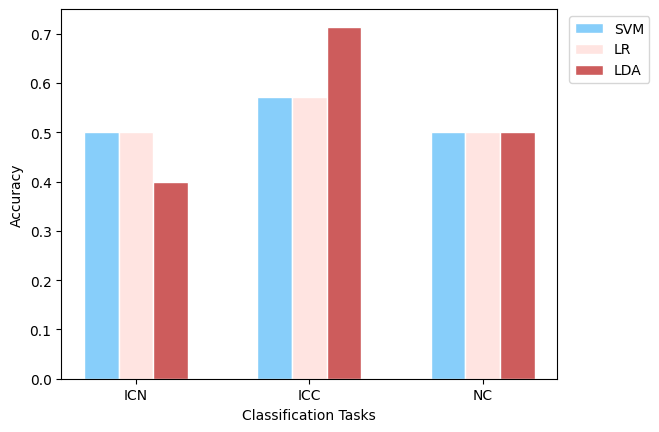

[[0.5, 0.5, 0.4], [0.5714285714285714, 0.5714285714285714, 0.7142857142857143], [0.5, 0.5, 0.5]]


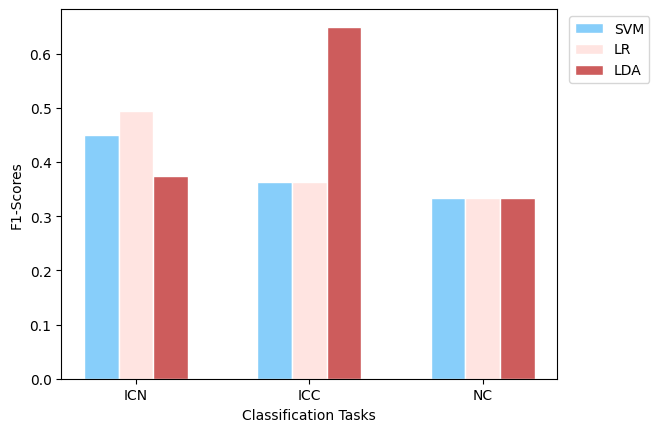

In [7]:
def plotEvalMetrics(tasks, labels, evalMetric, metricName):
    width = 0.2  # the width of the bars

    # Set position of bar on X axis
    rects1 = np.arange(len(evalMetric[:][0]))
    rects2 = [x + width for x in rects1]
    rects3 = [x + width for x in rects2]

    plt.bar(rects1, list(zip(*evalMetric))[0], color='#87CEFA', width=width, edgecolor='white', label=labels[0])
    plt.bar(rects2, list(zip(*evalMetric))[1], color='#FFE4E1', width=width, edgecolor='white', label=labels[1])
    plt.bar(rects3, list(zip(*evalMetric))[2], color='#CD5C5C', width=width, edgecolor='white', label=labels[2])

    plt.xlabel('Classification Tasks')
    plt.xticks([r + width for r in range(len(evalMetric[:][0]))], tasks)
    plt.ylabel(metricName)

    plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', )
    plt.show()

#Plot Accuracies
tasks = ['ICN', 'ICC', 'NC']
labels = ['SVM', 'LR', 'LDA']
plotEvalMetrics(tasks, labels, accuracies, 'Accuracy')
print(accuracies)

#Plot F1 Scores
tasks = ['ICN', 'ICC', 'NC']
labels = ['SVM', 'LR', 'LDA']
plotEvalMetrics(tasks, labels, f1_scores, 'F1-Scores')